# Modelagem: Curva de Demanda e Otimização de Preços

Consome o único modelo vencedor decidido nas análises exploratórias (`notebooks/01-EDA-regressao_robusta.ipynb`,
confirmado de forma cruzada com `notebooks/01-EDA-inicial.ipynb`): 4 grupos de dia da semana (Pico / TerQuaQui / Fraco /
FimDeSemana), elasticidade única, ajustado por regressão robusta de Huber sobre o Volume observado, sem nenhum
capping ou remoção prévia de outlier — a implementação de referência (`src/modeling/demand_curve.py`) faz exatamente
esse ajuste a partir dos dados brutos de treino. Este notebook não reajusta nada do zero e não depende de nenhum
dado pré-processado: carrega diretamente o treino/teste já separados (`data/interim/`) e chama a curva oficial.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
if not os.path.isdir('data'):
    os.chdir('..')
sys.path.insert(0, os.getcwd())

print(f"Diretório de trabalho atualizado para: {os.getcwd()}")


Diretório de trabalho atualizado para: /Users/ngodeny/Documents/mestrado/202602-resolucao_problemas


## Carregando os dados de treino e teste

Os mesmos 76 dias de treino (01/08 a 31/10/2025) e 10 dias de teste (03/11 a 14/11/2025) usados nas análises
exploratórias — sem nenhum tratamento de outlier aplicado antes da curva: a robustez a pontos extremos vem do
próprio método de ajuste (Huber), não de um corte prévio nos dados.

In [3]:
caminho_treino = 'data/interim/.treino.csv'
caminho_teste = 'data/interim/.teste.csv'

df_treino = pd.read_csv(caminho_treino, parse_dates=['Data'])
df_teste = pd.read_csv(caminho_teste, parse_dates=['Data'])

print(f"Treino: {len(df_treino)} dias ({df_treino['Data'].min().date()} a {df_treino['Data'].max().date()})")
print(f"Teste:  {len(df_teste)} dias ({df_teste['Data'].min().date()} a {df_teste['Data'].max().date()})")
df_treino[['Data', 'Dia da Semana', 'Preço', 'Volume Realizado (kg)']].head()


Treino: 76 dias (2025-08-01 a 2025-10-31)
Teste:  10 dias (2025-11-03 a 2025-11-14)


,Data,Dia da Semana,Preço,Volume Realizado (kg)
0,2025-08-01,Sexta,1267.949227,5.625635
1,2025-08-04,Segunda,1279.335771,31.390461
2,2025-08-05,Terça,1258.408986,22.184888
3,2025-08-06,Quarta,1241.133798,11.030794
4,2025-08-07,Quinta,1253.118993,15.160805


## Curva de demanda oficial (`src/modeling/demand_curve.py`)

`fit_demand_curve` deriva o grupo de cada dia a partir de `Dia da Semana` (`assign_cluster`) e ajusta a regressão
robusta de Huber sobre `ln(Volume Realizado (kg))` — nenhum dado precisa ser salvo ou pré-processado antes disso.

In [4]:
from src.modeling.demand_curve import fit_demand_curve, predict_volume, assign_cluster

modelo_demanda = fit_demand_curve(df_treino)

print("=== Coeficientes da curva de demanda oficial ===")
print(modelo_demanda.params.round(3))
print()
print("=== p-valores ===")
print(modelo_demanda.pvalues.round(4))


2026-09-12 14:54:34.171 | INFO     | src.config:<module>:11 - PROJ_ROOT path is: /Users/ngodeny/Documents/mestrado/202602-resolucao_problemas


=== Coeficientes da curva de demanda oficial ===
const          103.955
ln_Preco       -14.099
FimDeSemana     -2.759
Fraco           -1.288
Pico             0.296
dtype: float64

=== p-valores ===
const          0.0000
ln_Preco       0.0000
FimDeSemana    0.0000
Fraco          0.0000
Pico           0.0373
dtype: float64


## Validação fora da amostra

Erro percentual médio (MAPE) do modelo aplicado aos 10 dias de teste, nunca usados para decidir nenhum parâmetro
da curva.

In [5]:
df_teste = df_teste.copy()
df_teste['Cluster'] = df_teste['Dia da Semana'].apply(assign_cluster)
df_teste['Volume Previsto (kg)'] = df_teste.apply(
    lambda row: predict_volume(modelo_demanda, row['Preço'], row['Cluster']), axis=1
)
df_teste['Erro (%)'] = (
    (df_teste['Volume Realizado (kg)'] - df_teste['Volume Previsto (kg)']).abs()
    / df_teste['Volume Realizado (kg)'] * 100
)

mape_teste = df_teste['Erro (%)'].mean()
print(f"MAPE fora da amostra (10 dias de teste): {mape_teste:.1f}%")
df_teste[['Data', 'Dia da Semana', 'Cluster', 'Preço', 'Volume Realizado (kg)', 'Volume Previsto (kg)', 'Erro (%)']]


MAPE fora da amostra (10 dias de teste): 56.1%


,Data,Dia da Semana,Cluster,Preço,Volume Realizado (kg),Volume Previsto (kg),Erro (%)
0,2025-11-03,Segunda,Pico,1343.796759,29.906720,14.755936,50.660131
1,2025-11-04,Terça,TerQuaQui,1294.317204,9.467167,18.627766,96.761787
2,2025-11-05,Quarta,TerQuaQui,1311.528578,16.434609,15.462299,5.916232
3,2025-11-06,Quinta,TerQuaQui,1334.935036,17.256029,12.049248,30.173692
4,2025-11-07,Sexta,Fraco,1327.981999,1.176015,3.578177,204.262766
5,2025-11-10,Segunda,Pico,1334.796658,18.185917,16.222379,10.797028
6,2025-11-11,Terça,TerQuaQui,1302.994340,27.572620,16.953060,38.514876
7,2025-11-12,Quarta,TerQuaQui,1311.074297,21.366822,15.538008,27.279744
8,2025-11-13,Quinta,TerQuaQui,1318.273709,32.469452,14.383473,55.701523
9,2025-11-14,Sexta,Fraco,1282.923332,9.793182,5.821400,40.556606


## Simulação da curva por grupo

`Volume = A · Preço⁻ᴮ` para cada grupo, dentro da faixa de preço observada no treino — fora dela é extrapolação,
sem garantia estatística.

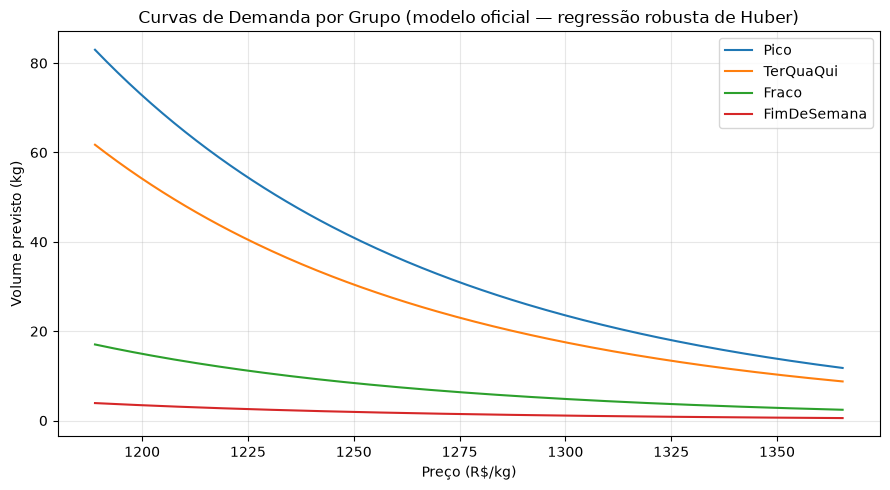

In [6]:
precos_simulados = np.linspace(df_treino['Preço'].min(), df_treino['Preço'].max(), 200)
grupos = ['Pico', 'TerQuaQui', 'Fraco', 'FimDeSemana']

plt.figure(figsize=(9, 5))
for grupo in grupos:
    volumes = [predict_volume(modelo_demanda, p, grupo) for p in precos_simulados]
    plt.plot(precos_simulados, volumes, label=grupo)

plt.title('Curvas de Demanda por Grupo (modelo oficial — regressão robusta de Huber)')
plt.xlabel('Preço (R$/kg)')
plt.ylabel('Volume previsto (kg)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Próximos passos: Otimização

Com a curva de demanda definida e validada, o passo seguinte é a Programação Matemática pedida no desafio: definir
a sequência de preços diários que maximiza a margem acumulada, sujeita a (1) meta semanal de volume (165 kg ± 30%)
e (2) variação máxima de preço entre dias consecutivos (R$ 2,00). Ainda não implementado neste notebook.